# RQ4

## Setup

* Follow the instructions on ```Readme.md``` 
* Inside the *pipeline* folder, run ```python -m src.rq4``` 
* Tested models: ```'microsoft/codebert-base', 'Salesforce/codet5-base'```
* Supported languages: ```'python', 'java' , 'cs'```
* Results are saved on ```results/RQ4```

## Datasets

In [2]:
from src.config import *

In [3]:
import json
import os
 
json_files = [
     KAMINO_LD_DATASET,
     KAMINO_MD_DATASET,
     KAMINO_HD_DATASET
]

def count_clones_in_json(file_path):
    """Counts total clones in a JSON file."""
    if not os.path.exists(file_path):
        print(f"⚠️ File not found: {file_path}")
        return 0

    with open(file_path, "r", encoding="utf-8") as f:
        data = json.load(f)
    
    total_clones = sum(len(entry.get("clones", [])) for entry in data)
    return total_clones

# Analyze all files

initial_count = None
for i, json_file in enumerate(json_files, 1):
    num_clones = count_clones_in_json(json_file)
    
    print(f"{num_clones} clones in {json_file}")


27527 clones in ../results/RQ4/datasets/bigcodebench_clone_dataset_ld.json
31157 clones in ../results/RQ4/datasets/bigcodebench_clone_dataset_md.json
⚠️ File not found: ../results/RQ4/datasets/bigcodebench_clone_dataset_hd.json
0 clones in ../results/RQ4/datasets/bigcodebench_clone_dataset_hd.json


In [4]:
import json
from itertools import combinations 

def count_positive_pairs(dataset, dataset_Name):
    with open(dataset, "r", encoding="utf-8") as f:
        data = json.load(f)

    seen_pairs = set()
    positive_pairs = 0

    for entry in data:

        clones = entry.get("clones", [])

        # Only consider entries with at least 2 clones
        if len(clones) < 2:
            continue

        # Clone-clone pairs
        for c1, c2 in combinations(clones, 2):

            code1 = c1["code"]
            code2 = c2["code"]

            key = tuple(sorted([code1, code2]))

            if key not in seen_pairs:
                seen_pairs.add(key)
                positive_pairs += 1

    print(
        f"Dataset {dataset_Name} has a total of "
        f"{positive_pairs} positive pairs excluding original_code"
    )

count_positive_pairs(KAMINO_LD_DATASET, "Kamino-LD")
count_positive_pairs(KAMINO_MD_DATASET, "Kamino-MD")
count_positive_pairs(KAMINO_HD_DATASET, "Kamino-HD")

Dataset Kamino-LD has a total of 547784 positive pairs excluding original_code
Dataset Kamino-MD has a total of 703934 positive pairs excluding original_code


FileNotFoundError: [Errno 2] No such file or directory: '../results/RQ4/datasets/bigcodebench_clone_dataset_hd.json'

## Results

In [1]:
csv_path = "../results/RQ4/best_results.csv"
PLOT_RESULTS = "../results/RQ4/plots/"

In [ ]:
import pandas as pd
import numpy as np

# Load CSV
csv_path = "../results/RQ4/clone_detection.csv"
df = pd.read_csv(csv_path)

THRESHOLD = 0.5        # set to None to disable filtering
SORT_BY = "f1"         # precision | recall | f1 | mcc | None
DESCENDING = True

if THRESHOLD is not None:
    df = df[np.isclose(df["threshold"], THRESHOLD)] 

if SORT_BY is not None:
    df = df.sort_values(by=SORT_BY, ascending=not DESCENDING)


display(
    df[[
        "model",
        "train_dataset",
        "test_dataset",
        "lan", 
        "threshold",
        "f1",
        "mcc",
    ]].round(4).reset_index(drop=True)
)
df.to_csv(csv_path, index=False)

,model,train_dataset,test_dataset,lan,threshold,f1,mcc
0,microsoft/codebert-base,Kamino-LD,GPTCloneBench,csharp,0.5,0.9418,0.8922
1,Salesforce/codet5-base,Kamino-LD,GPTCloneBench,csharp,0.5,0.9309,0.8752
2,microsoft/codebert-base,Kamino-LD,GPTCloneBench,java,0.5,0.8953,0.8144
3,microsoft/codebert-base,Kamino-LD,GPTCloneBench,python,0.5,0.8824,0.7994
4,Salesforce/codet5-base,Kamino-LD,GPTCloneBench,java,0.5,0.8682,0.7764
5,Salesforce/codet5-base,Kamino-LD,GPTCloneBench,python,0.5,0.8581,0.7665
6,Salesforce/codet5-base,Kamino-LD,SemanticCloneBench,csharp,0.5,0.7520,0.6508
7,microsoft/codebert-base,Kamino-LD,SemanticCloneBench,csharp,0.5,0.7467,0.6415
8,microsoft/codebert-base,Kamino-LD,SemanticCloneBench,python,0.5,0.7246,0.6182
9,Salesforce/codet5-base,Kamino-LD,SemanticCloneBench,python,0.5,0.7059,0.6000


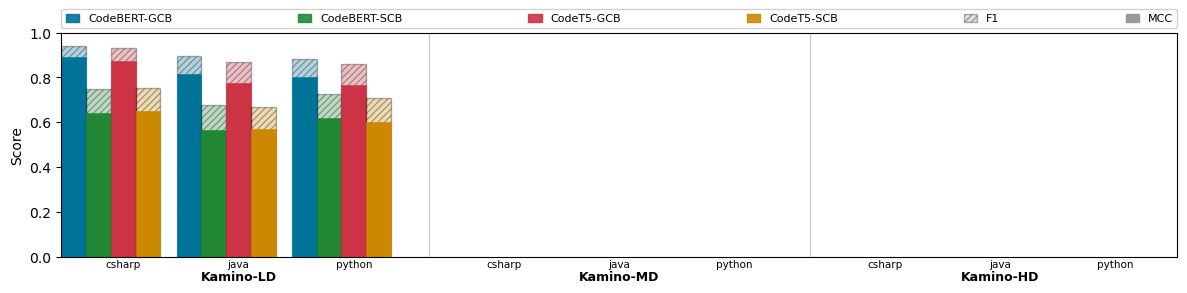

In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import os

df = pd.read_csv(csv_path)
df = df[df["model"] != "model"]

for col in ["f1", "mcc"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=["f1", "mcc"])

df["test"] = df["test_dataset"].map({
    "GPTCloneBench": "GCB",
    "SemanticCloneBench": "SCB"
})

df["model"] = df["model"].apply(
    lambda x: "CodeBERT" if "codebert" in x.lower()
    else "CodeT5" if "codet5" in x.lower()
    else x
)

df["variant"] = df["train_dataset"]
order = ["Kamino-LD", "Kamino-MD", "Kamino-HD"]

agg = df.groupby(
    ["model", "test", "variant", "lan"],
    as_index=False
)[["f1", "mcc"]].mean()

combos = [
    ("CodeBERT", "GCB"),
    ("CodeBERT", "SCB"),
    ("CodeT5", "GCB"),
    ("CodeT5", "SCB")
]

color_map = {
    ("CodeBERT", "GCB"): "#007399",
    ("CodeBERT", "SCB"): "#228833",
    ("CodeT5", "GCB"): "#CC3344",
    ("CodeT5", "SCB"): "#CC8800",
}

languages = sorted(df["lan"].dropna().unique())

n_combos = len(combos)
n_lang = len(languages)

bar_w = 0.12
lang_gap = 0.08
variant_gap = 0.25

lang_group_w = n_combos * bar_w
variant_group_w = n_lang * lang_group_w + (n_lang - 1) * lang_gap
variant_origins = np.arange(len(order)) * (variant_group_w + variant_gap)

fig, ax = plt.subplots(figsize=(12, 3.5))

for vi, variant in enumerate(order):
    v_origin = variant_origins[vi]
    lang_centers = []

    for li, lang in enumerate(languages):
        lang_origin = v_origin + li * (lang_group_w + lang_gap)
        lang_centers.append(lang_origin + lang_group_w / 2)

        for ci, (model, test) in enumerate(combos):
            color = color_map[(model, test)]
            pos = lang_origin + ci * bar_w

            g = agg[
                (agg["model"] == model) &
                (agg["test"] == test) &
                (agg["lan"] == lang) &
                (agg["variant"] == variant)
            ]

            f1_val  = g["f1"].values[0]  if len(g) else np.nan
            mcc_val = g["mcc"].values[0] if len(g) else np.nan

            ax.bar(pos, f1_val, bar_w,
                   color=color, alpha=0.3,
                   edgecolor="black", linewidth=1, hatch="/////")

            ax.bar(pos, mcc_val, bar_w,
                   color=color, alpha=1,
                   edgecolor=color, linewidth=0.4)

    variant_center = v_origin + variant_group_w / 2

    for lang, lc in zip(languages, lang_centers):
        ax.text(lc, -0.01, lang,
                transform=ax.get_xaxis_transform(),
                ha="center", va="top", fontsize=7.5, color="black")

    ax.text(variant_center, -0.06, variant,
            transform=ax.get_xaxis_transform(),
            ha="center", va="top", fontsize=9, fontweight="bold")

    for li in range(1, n_lang):
        sx = v_origin + li * (lang_group_w + lang_gap) - lang_gap / 2 

for vi in range(1, len(order)):
    sx = variant_origins[vi] - variant_gap / 2
    ax.axvline(sx, color="gray", linewidth=1, linestyle="-", alpha=0.4)

ax.set_xticks([])
ax.tick_params(axis="x", length=0)
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.grid(axis="x", alpha=0)
ax.set_xlim(-bar_w * 0.5, variant_origins[-1] + variant_group_w + bar_w * 0.5)

color_patches = [
    mpatches.Patch(facecolor=color_map[k], alpha=0.9, edgecolor=color_map[k],
                   label=f"{k[0]}-{k[1]}")
    for k in combos
]

hatch_patches = [
    mpatches.Patch(facecolor="#999", alpha=0.3, hatch="/////",
                   edgecolor="black", linewidth=1, label="F1"),
    mpatches.Patch(facecolor="#999", alpha=1, edgecolor="#999", label="MCC"),
]

ax.legend(
    handles=color_patches + hatch_patches,
    fontsize=8,
    ncol=6,
    loc="lower left",
    bbox_to_anchor=(0, 1.02, 1, 0.1),
    mode="expand",
    borderaxespad=0,
    framealpha=0.9,
    handlelength=1.2,
)

ax.set_xlim(-bar_w * 0.5, variant_origins[-1] + variant_group_w + bar_w * 0.5)

# Remove tight_layout + subplots_adjust, use this instead:
fig.subplots_adjust(left=0.06, right=0.99, top=0.82, bottom=0.18)

pdf_path = os.path.join(PLOT_RESULTS, "RQ4Results.pdf")
plt.savefig(pdf_path, format="pdf", bbox_inches="tight", dpi=300)
plt.show()